# Craigslist Cars & Trucks — Data Cleaning, Feature Engineering & EDA

Notebook for loading, cleaning, feature engineering, exploratory analysis, visualization, and summary reporting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

df = pd.read_csv("/run/media/varun-chouhan/Z/VARUN/Learning&Projects/Learning/eda_Craigslist/data/vehicles.csv")

# Initial Inspection

In [3]:
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print("Shape:", df.shape)
print("Columns:")
print(df.columns.tolist())
print("Data types:")
display(df.dtypes.to_frame("dtype"))

Rows: 426,880
Columns: 26
Shape: (426880, 26)
Columns:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']
Data types:


,dtype
id,int64
url,str
region,str
region_url,str
price,int64
year,float64
manufacturer,str
model,str
condition,str
cylinders,str


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-null  str    
 11  odometer      422480 non-null  float64
 12  title_status  418638 non-null  str    
 13  transmission  424324 non-null  str    
 14  VIN           265838 non-null  str    
 15  drive         296313 non-null  str    
 16  size          120519 non-null  str    
 17  type          334022 non-null  str    
 18  paint_color   2

In [5]:
df.describe()

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502


# Duplicate Analysis

In [6]:
duplicate_count = df.duplicated().sum()
print(f"Duplicate rows: {duplicate_count:,}")
print(f"Duplicate percentage: {duplicate_count / len(df) * 100:.2f}%")
df = df.drop_duplicates().copy()

Duplicate rows: 0
Duplicate percentage: 0.00%


# Standardize Column Names

In [7]:
df.columns = (df.columns.str.lower().str.strip().str.replace(" ", "_", regex=False))
print(df.columns.tolist())

['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'vin', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']


# Missing Value Analysis

In [8]:
missing = pd.DataFrame({"missing_count": df.isnull().sum(), "missing_percentage": df.isnull().mean()*100}).sort_values("missing_percentage", ascending=False)
display(missing)

,missing_count,missing_percentage
county,426880,100.000000
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
vin,161042,37.725356
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753


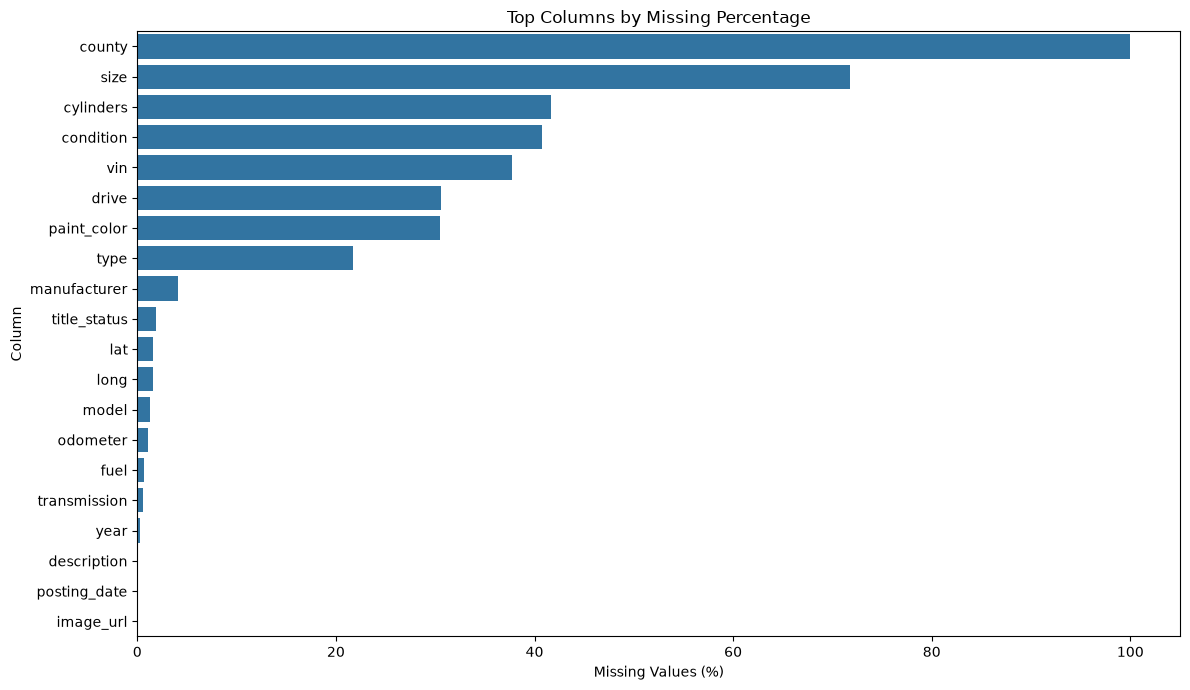

In [10]:
missing_plot = missing[missing.missing_count > 0].head(20)
plt.figure(figsize=(12,7))
sns.barplot(x=missing_plot.missing_percentage, y=missing_plot.index)
plt.title("Top Columns by Missing Percentage")
plt.xlabel("Missing Values (%)")
plt.ylabel("Column")
plt.tight_layout()
plt.show()

# Text and Categorical Cleaninig

In [11]:
text_columns = df.select_dtypes(include="object").columns
for col in text_columns:
    df[col] = df[col].astype("string").str.strip()
    df[col] = df[col].replace(["", "nan", "None", "null", "NULL"], pd.NA)

categorical_columns = ["condition","cylinders","fuel","title_status","transmission","drive","size","type","paint_color"]
for col in categorical_columns:
    if col in df.columns:
        df[col] = df[col].astype("string").str.lower().str.strip()

/run/media/varun-chouhan/Z/tmp/ipykernel_13168/1040709863.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_columns = df.select_dtypes(include="object").columns


# Numerical Cleaning

In [12]:
for col in ["price","year","odometer"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df = df[df["price"] > 0].copy()
df.loc[(df["year"] < 1900) | (df["year"] > 2026), "year"] = np.nan
df.loc[df["odometer"] <= 0, "odometer"] = np.nan
display(df[["price","year","odometer"]].describe())

,price,year,odometer
count,3.939850e+05,392812.000000,3.905810e+05
mean,8.147763e+04,2011.006115,9.901110e+04
std,1.268064e+07,9.630905,2.061416e+05
min,1.000000e+00,1900.000000,1.000000e+00
25%,7.000000e+03,2008.000000,3.838200e+04
50%,1.500000e+04,2013.000000,8.723600e+04
75%,2.759000e+04,2017.000000,1.355600e+05
max,3.736929e+09,2022.000000,1.000000e+07


# Feature Engineering

In [15]:
REFERENCE_YEAR = 2026
df["vehicle_age"] = REFERENCE_YEAR - df["year"]

df["age_group"] = pd.cut(df["vehicle_age"], bins=[-1,3,5,10,15,20,np.inf], labels=["0-3 years","4-5 years","6-10 years","11-15 years","16-20 years","20+ years"])

df["mileage_group"] = pd.cut(df["odometer"], bins=[-1,25000,50000,75000,100000,150000,np.inf], labels=["<25K","25K-50K","50K-75K","75K-100K","100K-150K","150K+"])

df["price_group"] = pd.cut(df["price"], bins=[0,10000,20000,30000,50000,100000,np.inf], labels=["<10K","10K-20K","20K-30K","30K-50K","50K-100K","100K+"])

df["price_per_mile"] = np.where(df["odometer"] > 0, df["price"] / df["odometer"], np.nan)
df["log_price"] = np.log1p(df["price"])
df["log_odometer"] = np.log1p(df["odometer"])
df

,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,vin,drive,size,type,paint_color,image_url,description,county,state,lat,long,posting_date,vehicle_age,age_group,mileage_group,price_group,price_per_mile,log_price,log_odometer
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,az,NaN,NaN,<NA>,NaN,NaN,NaN,<10K,NaN,8.699681,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,ar,NaN,NaN,<NA>,NaN,NaN,NaN,10K-20K,NaN,9.384378,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,fl,NaN,NaN,<NA>,NaN,NaN,NaN,20K-30K,NaN,9.952325,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,ma,NaN,NaN,<NA>,NaN,NaN,NaN,<10K,NaN,7.313887,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaN,nc,NaN,NaN,<NA>,NaN,NaN,NaN,<10K,NaN,8.497195,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
426875,7301591192,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,23590,2019.0,nissan,maxima s sedan 4d,good,6 cylinders,gas,32226.0,clean,other,1N4AA6AV6KC367801,fwd,<NA>,sedan,<NA>,https://images.craigslist.org/00o0o_iiraFnHg8q...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:31-0600,7.0,6-10 years,25K-50K,20K-30K,0.732018,10.068621,10.380560
426876,7301591187,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,30590,2020.0,volvo,s60 t5 momentum sedan 4d,good,<NA>,gas,12029.0,clean,other,7JR102FKXLG042696,fwd,<NA>,sedan,red,https://images.craigslist.org/00x0x_15sbgnxCIS...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:29-0600,6.0,6-10 years,<25K,30K-50K,2.543021,10.328461,9.395159
426877,7301591147,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,34990,2020.0,cadillac,xt4 sport suv 4d,good,<NA>,diesel,4174.0,clean,other,1GYFZFR46LF088296,<NA>,<NA>,hatchback,white,https://images.craigslist.org/00L0L_farM7bxnxR...,Carvana is the safer way to buy a car During t...,NaN,wy,33.779214,-84.411811,2021-04-04T03:21:17-0600,6.0,6-10 years,<25K,30K-50K,8.382846,10.462846,8.336870
426878,7301591140,https://wyoming.craigslist.org/ctd/d/atlanta-2...,wyoming,https://wyoming.craigslist.org,28990,2018.0,lexus,es 350 sedan 4d,good,6 cylinders,gas,30112.0,clean,other,58ABK1GG4JU103853,fwd,<NA>,sedan,silver,https://images.craigslist.org/00z0z_bKnIVGLkDT...,Carvana is the safer way to buy a car During t...,NaN,wy,33.786500,-84.445400,2021-04-04T03:21:11-0600,8.0,6-10 years,25K-50K,20K-30K,0.962739,10.274741,10.312712


# Price Outlier Handling for Visualization

In [16]:
price_upper = df["price"].quantile(0.99)
df_analysis = df[df["price"] <= price_upper].copy()
print(f"Cleaned rows: {len(df):,}")
print(f"Rows used for price visualizations: {len(df_analysis):,}")
print(f"99th percentile price: ${price_upper:,.2f}")

Cleaned rows: 393,985
Rows used for price visualizations: 390,045
99th percentile price: $68,747.48


## Exploratory Data Analysis

# Price Distribution

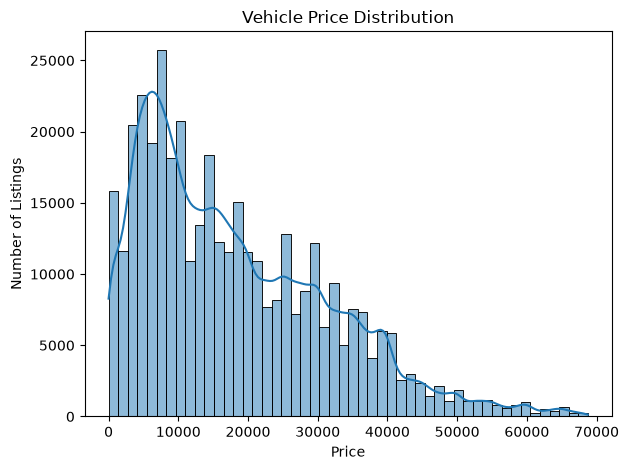

In [17]:
sns.histplot(df_analysis["price"], bins=50, kde=True)
plt.title("Vehicle Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

# Vehicle year distrubution

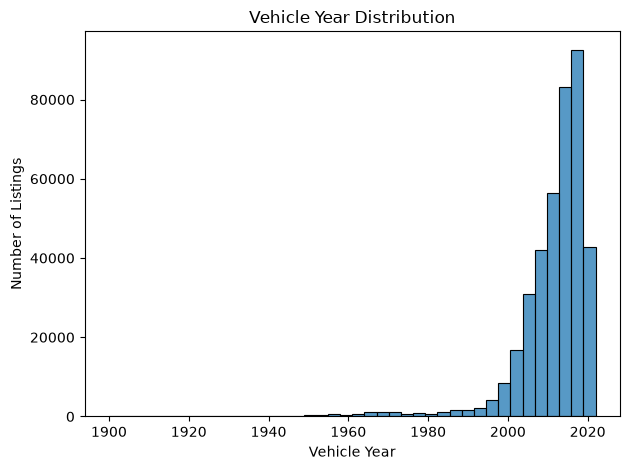

In [18]:
sns.histplot(df["year"].dropna(), bins=40)
plt.title("Vehicle Year Distribution")
plt.xlabel("Vehicle Year")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

# Vehical Age Distribution

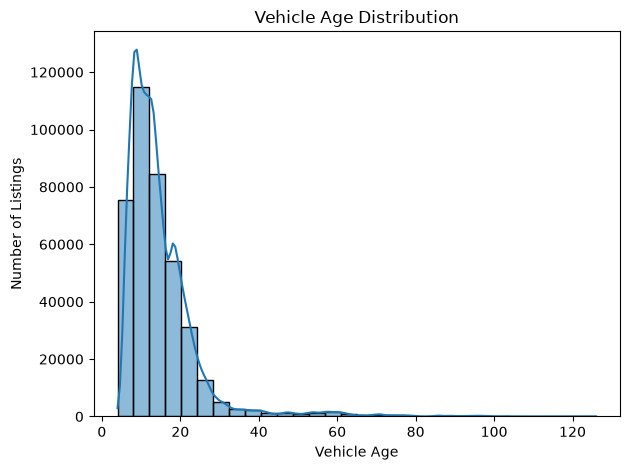

In [19]:
sns.histplot(df["vehicle_age"].dropna(), bins=30, kde=True)
plt.title("Vehicle Age Distribution")
plt.xlabel("Vehicle Age")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

## Odometer Distribution

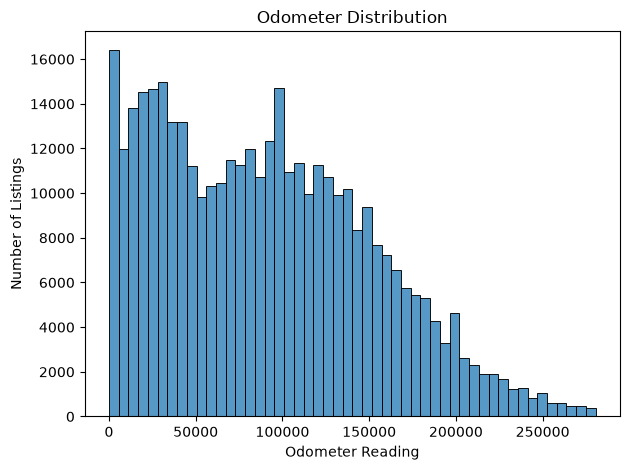

In [20]:
odometer_plot = df[df["odometer"] <= df["odometer"].quantile(0.99)]
sns.histplot(odometer_plot["odometer"].dropna(), bins=50)
plt.title("Odometer Distribution")
plt.xlabel("Odometer Reading")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

## Top Manufacturers

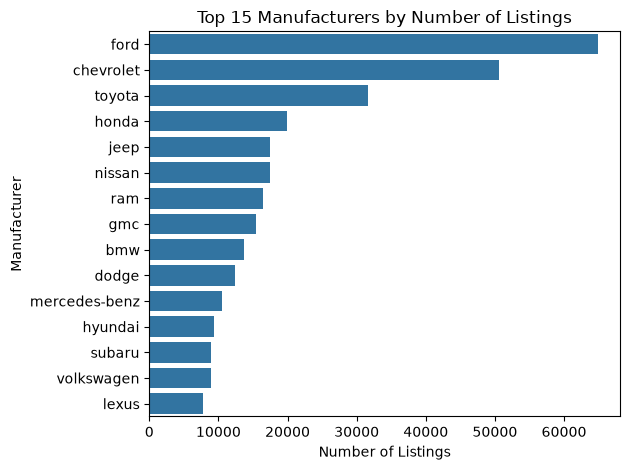

In [21]:
x = df["manufacturer"].value_counts().head(15)
sns.barplot(x=x.values, y=x.index)
plt.title("Top 15 Manufacturers by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Manufacturer")
plt.tight_layout()
plt.show()

## Top Models

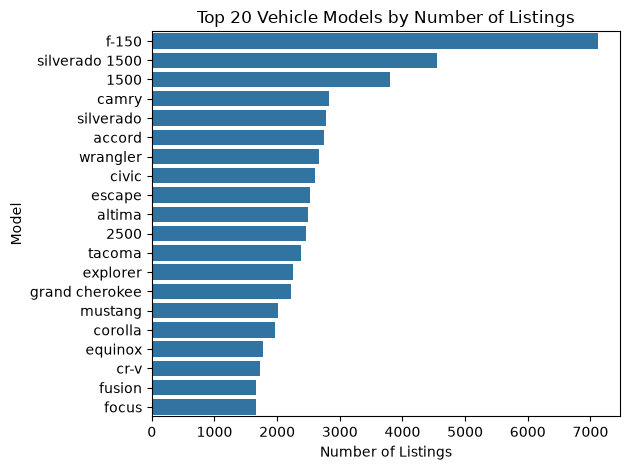

In [22]:
x = df["model"].value_counts().head(20)
sns.barplot(x=x.values, y=x.index)
plt.title("Top 20 Vehicle Models by Number of Listings")
plt.xlabel("Number of Listings")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

## Vehicle Type Distribution

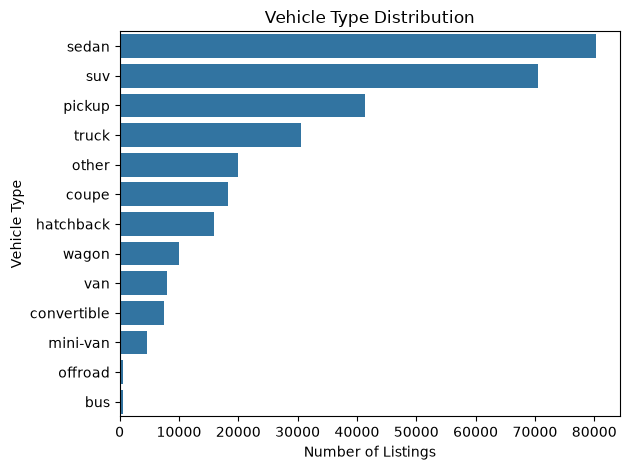

In [23]:
x = df["type"].value_counts().head(15)
sns.barplot(x=x.values, y=x.index)
plt.title("Vehicle Type Distribution")
plt.xlabel("Number of Listings")
plt.ylabel("Vehicle Type")
plt.tight_layout()
plt.show()

## Fuel, Transmission and Condition

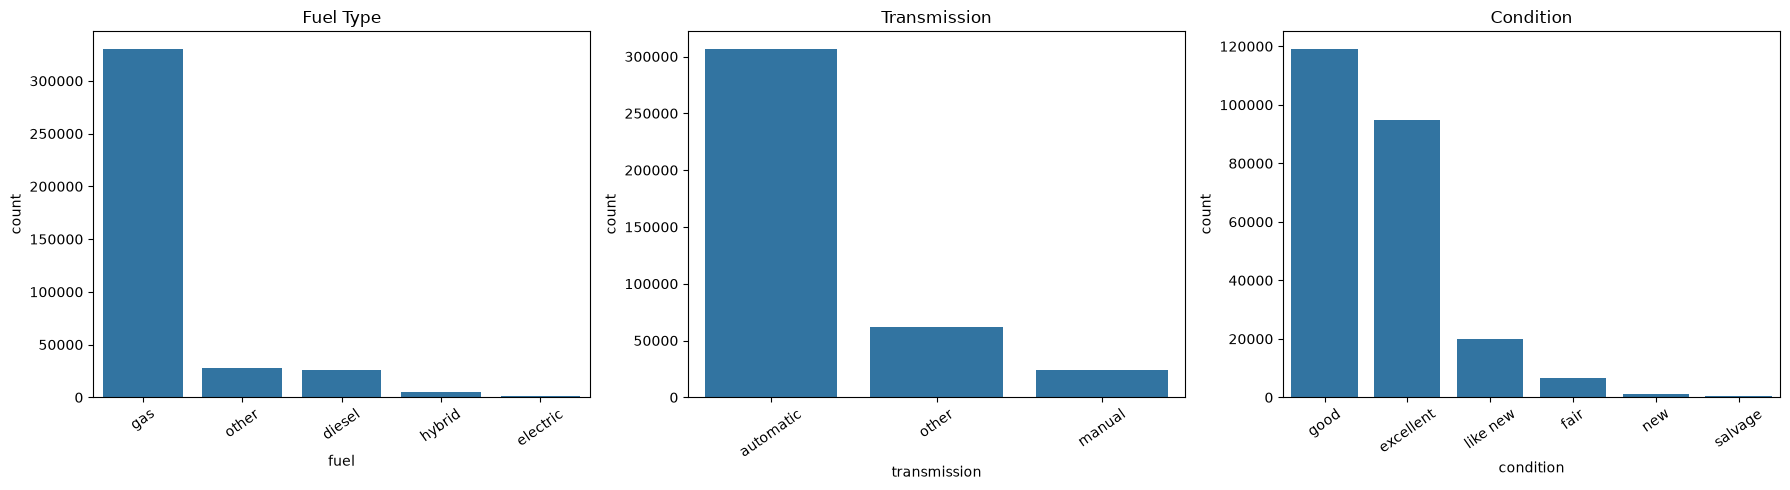

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, col, title in zip(axes, ["fuel","transmission","condition"], ["Fuel Type","Transmission","Condition"]):
    order = df[col].value_counts().index
    sns.countplot(data=df, x=col, order=order, ax=ax)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
plt.show()

## Price vs Odometer

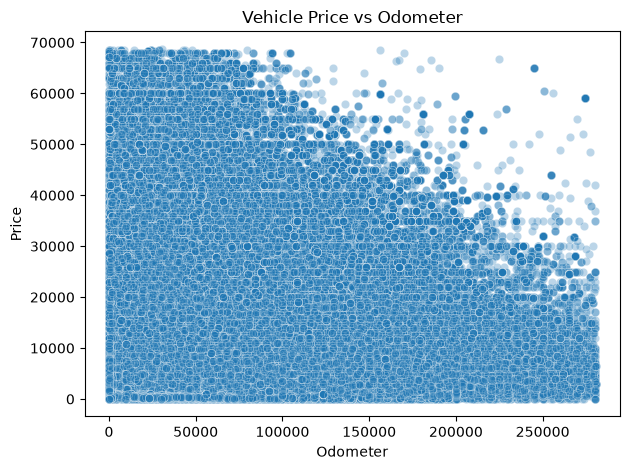

In [25]:
plot_df = df[(df["price"] <= df["price"].quantile(.99)) & (df["odometer"] <= df["odometer"].quantile(.99))]
sns.scatterplot(data=plot_df, x="odometer", y="price", alpha=.3)
plt.title("Vehicle Price vs Odometer")
plt.xlabel("Odometer")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

## Price vs Vehicle Age

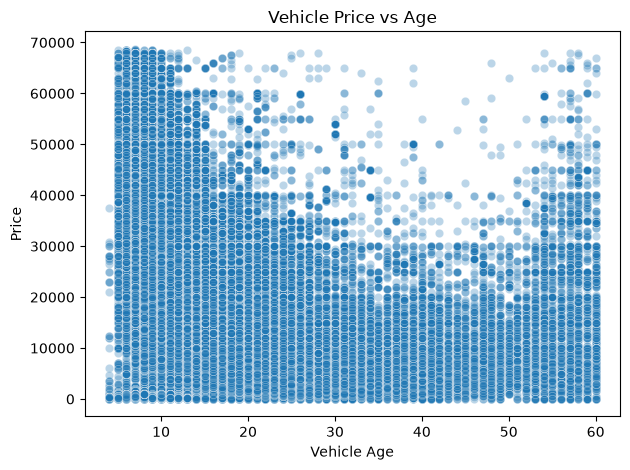

In [26]:
plot_df = df[(df["price"] <= df["price"].quantile(.99)) & (df["vehicle_age"] <= df["vehicle_age"].quantile(.99))]
sns.scatterplot(data=plot_df, x="vehicle_age", y="price", alpha=.3)
plt.title("Vehicle Price vs Age")
plt.xlabel("Vehicle Age")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

## Price by Vehicle Type

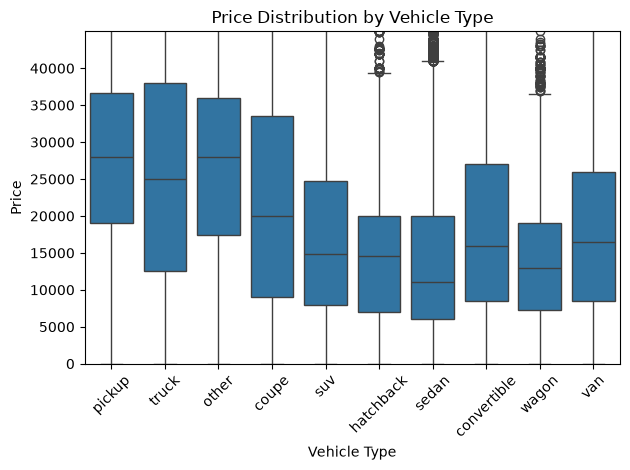

In [27]:
top_types = df["type"].value_counts().head(10).index
tmp = df[df["type"].isin(top_types)]
sns.boxplot(data=tmp, x="type", y="price")
plt.title("Price Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Price")
plt.ylim(0, df["price"].quantile(.95))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Price by Manufacturer

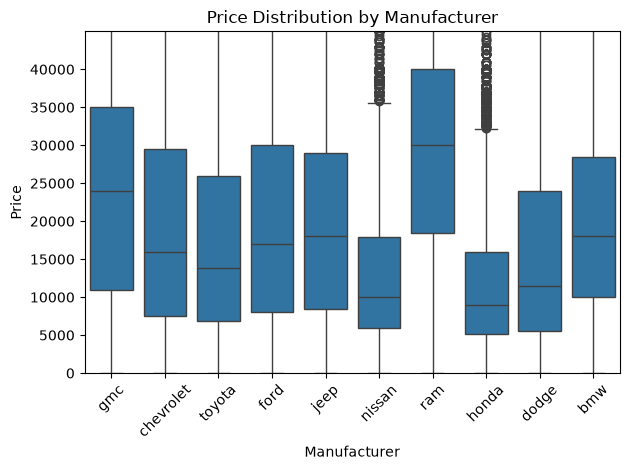

In [28]:
top_m = df["manufacturer"].value_counts().head(10).index
tmp = df[df["manufacturer"].isin(top_m)]
sns.boxplot(data=tmp, x="manufacturer", y="price")
plt.title("Price Distribution by Manufacturer")
plt.xlabel("Manufacturer")
plt.ylabel("Price")
plt.ylim(0, df["price"].quantile(.95))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Price by Condition

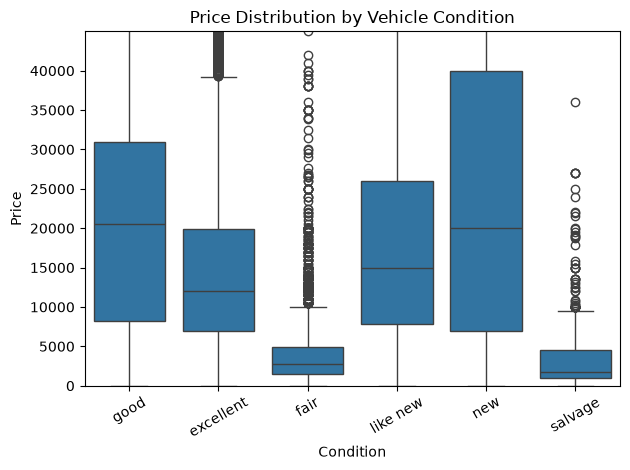

In [29]:
sns.boxplot(data=df, x="condition", y="price")
plt.title("Price Distribution by Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Price")
plt.ylim(0, df["price"].quantile(.95))
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## Median Price by Mileage and Age Group

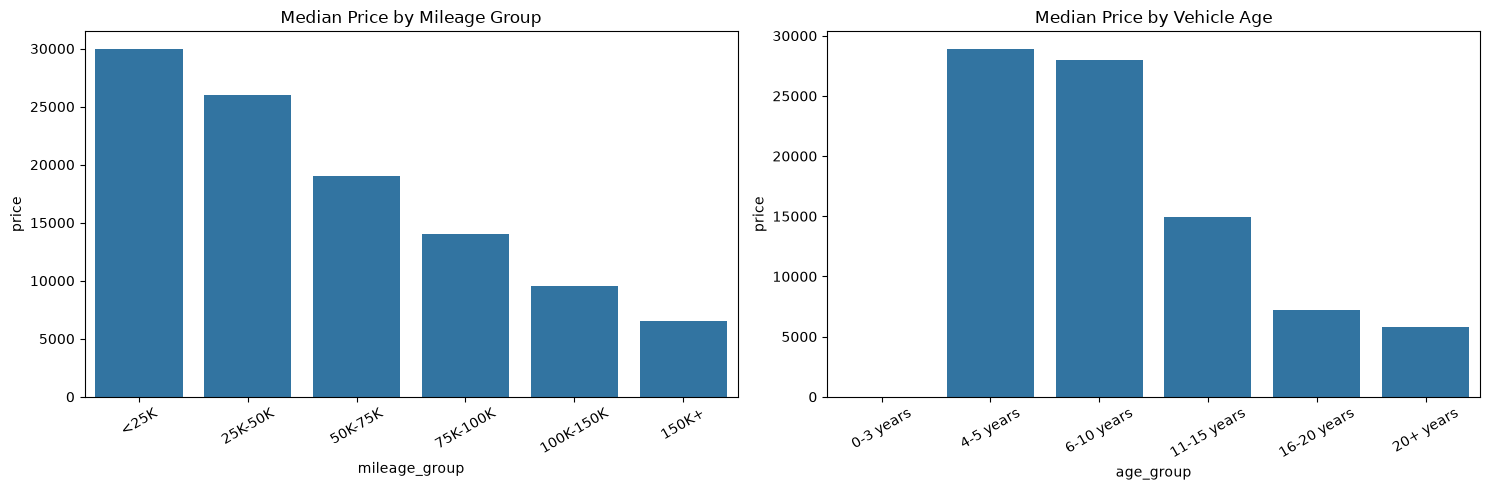

In [32]:
fig, axes = plt.subplots(1,2, figsize=(15,5))
mp = df.groupby("mileage_group", observed=True)["price"].median().reset_index()
ap = df.groupby("age_group", observed=True)["price"].median().reset_index()
sns.barplot(data=mp, x="mileage_group", y="price", ax=axes[0])
axes[0].set_title("Median Price by Mileage Group")
axes[0].tick_params(axis="x", rotation=30)
sns.barplot(data=ap, x="age_group", y="price", ax=axes[1])
axes[1].set_title("Median Price by Vehicle Age")
axes[1].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Correlation Heatmap

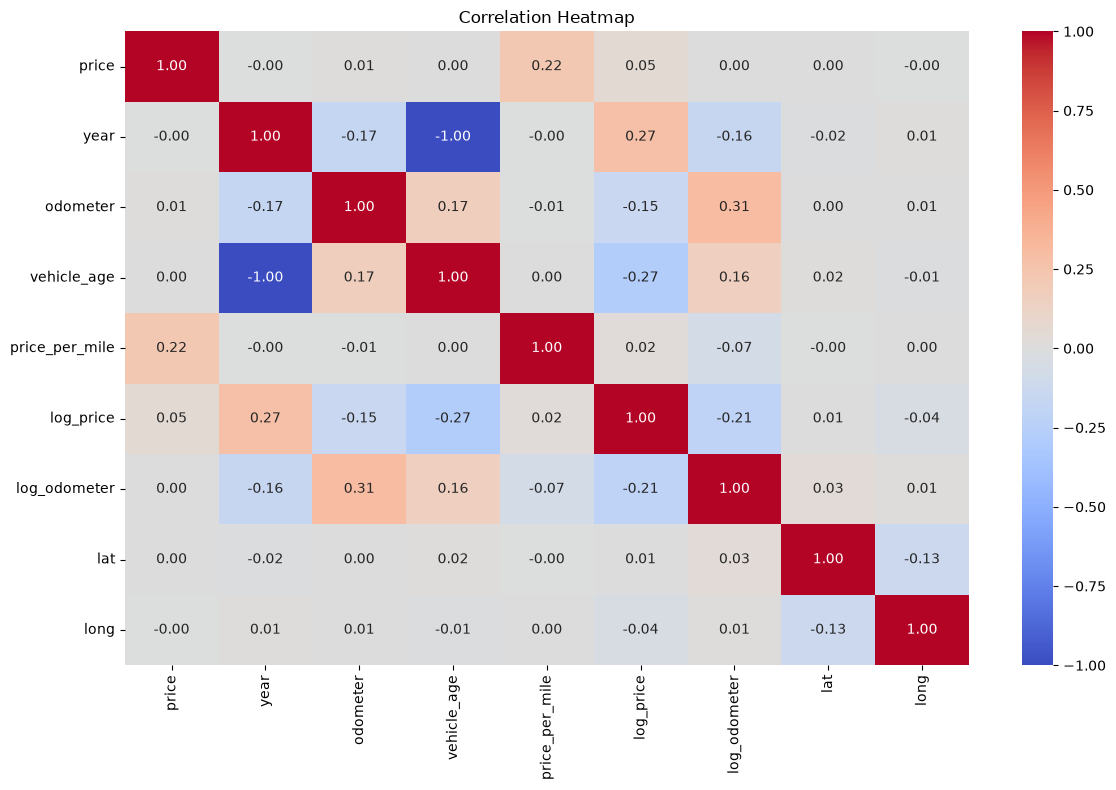

In [33]:
numeric_columns = [c for c in ["price","year","odometer","vehicle_age","price_per_mile","log_price","log_odometer","lat","long"] if c in df.columns]
corr = df[numeric_columns].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## Listings by State

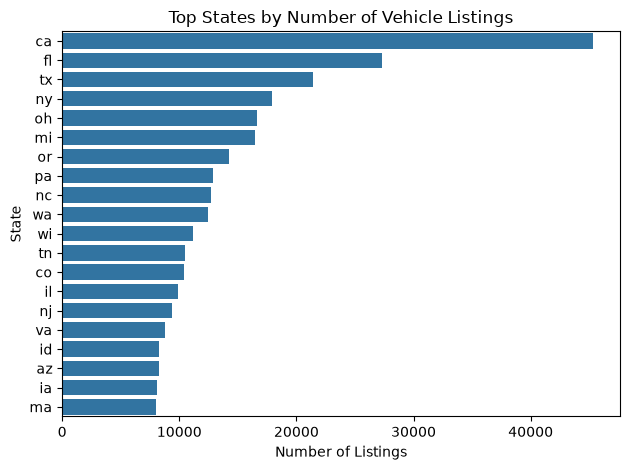

In [34]:
x = df["state"].value_counts().head(20)
sns.barplot(x=x.values, y=x.index)
plt.title("Top States by Number of Vehicle Listings")
plt.xlabel("Number of Listings")
plt.ylabel("State")
plt.tight_layout()
plt.show()

## State-Level Price Summary

In [35]:
state_price = df.groupby("state")["price"].agg(median_price="median", average_price="mean", listing_count="count").sort_values("listing_count", ascending=False)
state_price.head(20)

,median_price,average_price,listing_count
state,,,
ca,14985.0,134037.580194,45359
fl,14900.0,18633.268378,27316
tx,18500.0,22909.605698,21377
ny,14995.0,18378.668621,17907
oh,11995.0,28521.151961,16649
mi,11450.0,30927.169111,16433
or,13000.0,280871.298597,14260
pa,11800.0,16565.997365,12903
nc,16990.0,39496.330761,12698


## Manufacturer vs Condition

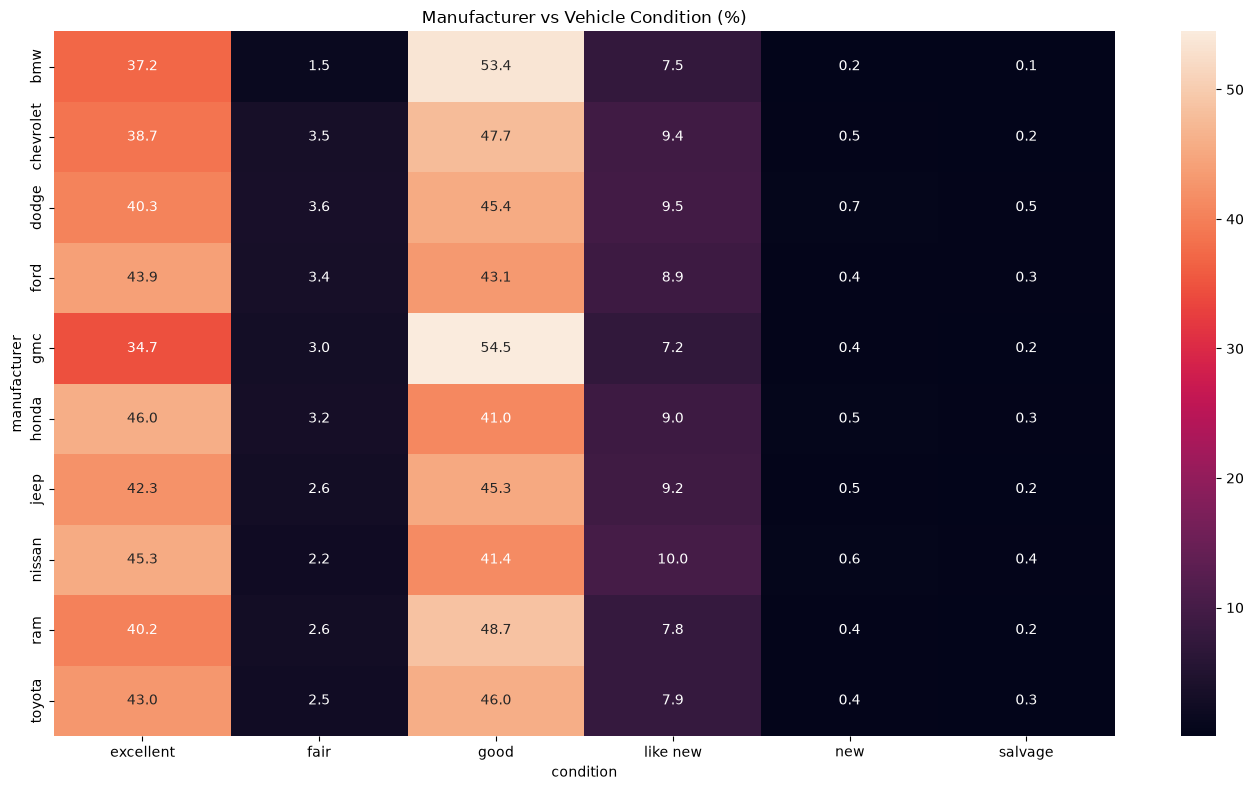

In [36]:
top_m = df["manufacturer"].value_counts().head(10).index
tmp = df[df["manufacturer"].isin(top_m)]
table = pd.crosstab(tmp["manufacturer"], tmp["condition"], normalize="index") * 100
plt.figure(figsize=(14,8))
sns.heatmap(table, annot=True, fmt=".1f")
plt.title("Manufacturer vs Vehicle Condition (%)")
plt.tight_layout()
plt.show()

## Summary Tables

In [37]:
manufacturer_summary = df.groupby("manufacturer").agg(listings=("price","count"), median_price=("price","median"), average_price=("price","mean"), median_odometer=("odometer","median"), median_age=("vehicle_age","median")).sort_values("listings", ascending=False)
manufacturer_summary.head(20)

vehicle_type_summary = df.groupby("type").agg(listings=("price","count"), median_price=("price","median"), average_price=("price","mean"), median_odometer=("odometer","median")).sort_values("listings", ascending=False)
vehicle_type_summary.head(20)

,listings,median_price,average_price,median_odometer
type,,,,
sedan,80322,10995.0,17287.409576,81130.0
suv,70599,14900.0,37694.598096,95803.0
pickup,41373,27999.0,152228.357552,69966.5
truck,30634,24995.0,33838.977868,103832.0
other,19873,27990.0,27528.844160,39087.0
coupe,18214,19990.0,23129.953223,53066.0
hatchback,15917,14590.0,14999.946786,54797.5
wagon,10064,12983.5,14180.028120,91278.0
van,7974,16500.0,18746.423000,96982.0


## Final Data Quality Report

In [38]:
final_quality = pd.DataFrame({"column":df.columns, "dtype":df.dtypes.astype(str).values, "missing_count":df.isnull().sum().values, "missing_percentage":df.isnull().mean().values*100, "unique_values":[df[c].nunique(dropna=True) for c in df.columns]}).sort_values("missing_percentage", ascending=False)
final_quality

,column,dtype,missing_count,missing_percentage,unique_values
21,county,float64,393985,100.000000,0
16,size,string,282933,71.813140,4
9,cylinders,string,160410,40.714748,8
14,vin,string,152158,38.620252,105829
8,condition,string,151389,38.425067,6
15,drive,string,120254,30.522482,3
18,paint_color,string,117149,29.734381,12
17,type,string,85932,21.810983,13
6,manufacturer,string,16185,4.108024,42
12,title_status,string,7734,1.963019,6


## Overall Dataset Summary

In [39]:
print(f"Total listings: {len(df):,}")
print(f"Total columns: {df.shape[1]}")
print(f"Average price: ${df.price.mean():,.2f}")
print(f"Median price: ${df.price.median():,.2f}")
print(f"Average mileage: {df.odometer.mean():,.0f}")
print(f"Median mileage: {df.odometer.median():,.0f}")
print(f"Median vehicle age: {df.vehicle_age.median():.1f} years")
print(f"Unique manufacturers: {df.manufacturer.nunique():,}")
print(f"Unique models: {df.model.nunique():,}")

Total listings: 393,985
Total columns: 33
Average price: $81,477.63
Median price: $15,000.00
Average mileage: 99,011
Median mileage: 87,236
Median vehicle age: 13.0 years
Unique manufacturers: 42
Unique models: 28,281
